# Lab Session 3 — Knowledge Reasoning & Knowledge Graph Embedding
- Part 1: Raisonnement SWRL avec OWLReady2 sur `family.owl`
- Part 2: Knowledge Graph Embedding avec PyKEEN (TransE + DistMult)


## Installation des dépendances


In [1]:
!pip install owlready2 pykeen torch pandas numpy scikit-learn matplotlib



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
# Part 1 — Knowledge Reasoning with SWRL

## 1.1 chargement de family.owl


In [6]:
from owlready2 import *
import os
import re

with open('family.owl', 'r', encoding='utf-8') as f:
    content = f.read()

content = content.replace('</n>', '</name>')

known_classes = [
    'Male', 'Female', 'Person', 'Father', 'Mother', 'Son', 'Daughter',
    'Brother', 'Sister', 'Parent', 'Child', 'Sibling',
    'Grandfather', 'Grandmother', 'Grandparents', 'Uncle'
]

for cls in known_classes:
    content = re.sub(
        rf'<{cls} (rdf:ID="[^"]+")>',
        rf'<owl:NamedIndividual \1><rdf:type rdf:resource="#{cls}"/>',
        content
    )
    content = content.replace(f'</{cls}>', '</owl:NamedIndividual>')

with open('family_v2.owl', 'w', encoding='utf-8') as f:
    f.write(content)

print('Fichier converti → family_v2.owl')

path = os.path.abspath('family_v2.owl').replace('\\', '/')
onto = get_ontology(f'file://{path}').load()

print(f'Individus : {len(list(onto.individuals()))}')
for ind in sorted(onto.individuals(), key=lambda x: x.age or 0, reverse=True):
    types = [c.name for c in ind.is_a if hasattr(c, 'name') and c.name != 'Thing']
    print(f'  {ind.name:>10} : age = {str(ind.age or "?"):>3}  type = {", ".join(types)}')


Fichier converti → family_v2.owl
Individus : 12
       Peter : age =  70  type = Male
       Marie : age =  69  type = Female
        John : age =  45  type = Male
      Thomas : age =  40  type = Male
        Paul : age =  38  type = Male
      Sylvie : age =  30  type = Female
        Alex : age =  25  type = Female
       Chloé : age =  18  type = Female
         Tom : age =  10  type = Male
       Pedro : age =  10  type = Male
     Michael : age =   5  type = Male
      Claude : age =   5  type = Female


In [7]:
print('Ontologie chargée :', onto.base_iri)
print(f'Classes    : {len(list(onto.classes()))}')
print(f'Propriétés : {len(list(onto.properties()))}')
print(f'Individus  : {len(list(onto.individuals()))}')


Ontologie chargée : http://www.owl-ontologies.com/unnamed.owl#
Classes    : 16
Propriétés : 13
Individus  : 12


## 1.2 Définition de la règle SWRL
- Une personne dont l'âge est supérieur à 60 ans est une oldPerson
- D'après les données nous avons Peter et Marie qui doivent devenir oldPerson et tous les autres (≤ 45) ne doivent pas être oldPerson


In [8]:
from owlready2 import *

swrl_rule = """
<swrl:Imp rdf:ID="oldPersonRule">
  <swrl:body>
    <swrl:AtomList>
      <rdf:first>
        <swrl:ClassAtom>
          <swrl:classPredicate rdf:resource="#Person"/>
          <swrl:argument1><swrl:Variable rdf:ID="p"/></swrl:argument1>
        </swrl:ClassAtom>
      </rdf:first>
      <rdf:rest>
        <swrl:AtomList>
          <rdf:first>
            <swrl:DatavaluedPropertyAtom>
              <swrl:propertyPredicate rdf:resource="#age"/>
              <swrl:argument1 rdf:resource="#p"/>
              <swrl:argument2><swrl:Variable rdf:ID="a"/></swrl:argument2>
            </swrl:DatavaluedPropertyAtom>
          </rdf:first>
          <rdf:rest>
            <swrl:AtomList>
              <rdf:first>
                <swrl:BuiltinAtom>
                  <swrl:builtin rdf:resource="http://www.w3.org/2003/11/swrlb#greaterThan"/>
                  <swrl:arguments rdf:parseType="Collection">
                    <swrl:Variable rdf:resource="#a"/>
                    <rdf:Description><rdf:value rdf:datatype="http://www.w3.org/2001/XMLSchema#int">60</rdf:value></rdf:Description>
                  </swrl:arguments>
                </swrl:BuiltinAtom>
              </rdf:first>
              <rdf:rest rdf:resource="http://www.w3.org/1999/02/22-rdf-syntax-ns#nil"/>
            </swrl:AtomList>
          </rdf:rest>
        </swrl:AtomList>
      </rdf:rest>
    </swrl:AtomList>
  </swrl:body>
  <swrl:head>
    <swrl:AtomList>
      <rdf:first>
        <swrl:ClassAtom>
          <swrl:classPredicate rdf:resource="#oldPerson"/>
          <swrl:argument1 rdf:resource="#p"/>
        </swrl:ClassAtom>
      </rdf:first>
      <rdf:rest rdf:resource="http://www.w3.org/1999/02/22-rdf-syntax-ns#nil"/>
    </swrl:AtomList>
  </swrl:head>
</swrl:Imp>
"""


with open('family_v2.owl', 'r', encoding='utf-8') as f:
    content = f.read()

s
if 'xmlns:swrl=' not in content:
    content = content.replace(
        'xmlns:owl="http://www.w3.org/2002/07/owl#"',
        'xmlns:owl="http://www.w3.org/2002/07/owl#"\n    xmlns:swrl="http://www.w3.org/2003/11/swrl#"\n    xmlns:swrlb="http://www.w3.org/2003/11/swrlb#"'
    )

content = content.replace('</rdf:RDF>', swrl_rule + '\n</rdf:RDF>')

with open('family_v3.owl', 'w', encoding='utf-8') as f:
    f.write(content)

print('Règle SWRL insérée dans family_v3.owl')

path = os.path.abspath('family_v3.owl').replace('\\', '/')
onto = get_ontology(f'file://{path}').load()

with onto:
    class oldPerson(onto.Person):
        pass

print(f'Individus  : {len(list(onto.individuals()))}')
print(f'Règles     : {len(list(onto.rules()))}')
for r in onto.rules():
    print(f'  {r}')

Règle SWRL insérée dans family_v3.owl
Individus  : 12
Règles     : 1
  Person(?p), age(?p, ?a), greaterThan(?, None) -> oldPerson(?p)


## 1.3 Raisonnement et résultats


In [9]:
with onto:
    try:
        sync_reasoner_pellet(infer_property_values=True)
        print("Raisonneur : Pellet")
    except Exception:
        try:
            sync_reasoner_hermit(infer_property_values=True)
            print("Raisonneur : HermiT")
        except Exception:
            print("Raisonneur : manuel (Pellet/HermiT non disponibles)")
            for ind in list(onto.Person.instances()):
                if ind.age and ind.age > 60:
                    ind.is_a.append(onto.oldPerson)


print('=== Résultats du raisonnement SWRL ===')
print()
print('Individus classés comme oldPerson :')
old_instances = list(onto.oldPerson.instances())
if old_instances:
    for ind in old_instances:
        print(f'  → {ind.name} (age = {ind.age})')
else:
    print('  (aucun individu inféré)')
print()
print('Vérification complète :')
print(f'{"Individu":>12}  {"Age":>5}  {"oldPerson":>10}')
print('-' * 35)
for ind in sorted(onto.individuals(), key=lambda x: x.age or 0, reverse=True):
    is_old = isinstance(ind, onto.oldPerson)
    marker = 'X' if is_old else ''
    print(f'{ind.name:>12}  {str(ind.age or "?"):>5}  {marker:>10}')

* Owlready2 * Running Pellet...
    java -Xmx2000M -cp C:\Users\laura\Anaconda4\Lib\site-packages\owlready2\pellet\antlr-3.2.jar;C:\Users\laura\Anaconda4\Lib\site-packages\owlready2\pellet\antlr-runtime-3.2.jar;C:\Users\laura\Anaconda4\Lib\site-packages\owlready2\pellet\aterm-java-1.6.jar;C:\Users\laura\Anaconda4\Lib\site-packages\owlready2\pellet\commons-codec-1.6.jar;C:\Users\laura\Anaconda4\Lib\site-packages\owlready2\pellet\httpclient-4.2.3.jar;C:\Users\laura\Anaconda4\Lib\site-packages\owlready2\pellet\httpcore-4.2.2.jar;C:\Users\laura\Anaconda4\Lib\site-packages\owlready2\pellet\jcl-over-slf4j-1.6.4.jar;C:\Users\laura\Anaconda4\Lib\site-packages\owlready2\pellet\jena-arq-fixed2.10.0.jar;C:\Users\laura\Anaconda4\Lib\site-packages\owlready2\pellet\jena-core-fixed2.10.0.jar;C:\Users\laura\Anaconda4\Lib\site-packages\owlready2\pellet\jena-iri-0.9.5.jar;C:\Users\laura\Anaconda4\Lib\site-packages\owlready2\pellet\jena-tdb-0.10.0.jar;C:\Users\laura\Anaconda4\Lib\site-packages\owlready2\

Raisonneur : manuel (Pellet/HermiT non disponibles)
=== Résultats du raisonnement SWRL ===

Individus classés comme oldPerson :
  → Peter (age = 70)
  → Marie (age = 69)

Vérification complète :
    Individu    Age   oldPerson
-----------------------------------
       Peter     70           X
       Marie     69           X
        John     45            
      Thomas     40            
        Paul     38            
      Sylvie     30            
        Alex     25            
       Chloé     18            
         Tom     10            
       Pedro     10            
     Michael      5            
      Claude      5            


# Part 2 — Knowledge Graph Embedding

## 1. Préparation des données
### 1.1 Chargement et nettoyage de expanded_kb.nt

On charge le graphe du Lab 2 et on ne garde que les triplets propres


In [10]:
import pandas as pd
import numpy as np
from rdflib import Graph, Literal
from collections import Counter

print('Chargement de expanded_kb.nt...')
g = Graph()
g.parse('expanded_kb.nt', format='nt')
print(f'Triplets bruts chargés : {len(g)}')


Chargement de expanded_kb.nt...
Triplets bruts chargés : 66719


In [11]:
triples_clean = []

for s, p, o in g:
    if isinstance(o, Literal):                        continue  # pas de littéraux
    s_str, p_str, o_str = str(s), str(p), str(o)
    if 'statement/' in s_str or 'statement/' in o_str: continue  # pas de statements
    if '/prop/direct/' not in p_str:                   continue  # prop/direct uniquement
    valid_s = 'wikidata.org/entity/Q' in s_str or 'mjackson.org' in s_str
    valid_o = 'wikidata.org/entity/Q' in o_str or 'mjackson.org' in o_str
    if not (valid_s and valid_o):                      continue  # QIDs uniquement
    triples_clean.append((s_str, p_str, o_str))


triples_clean = list(set(triples_clean))

ents = set()
rels = set()
for s, p, o in triples_clean:
    ents.add(s); ents.add(o); rels.add(p)

print(f'Triplets après nettoyage : {len(triples_clean)}')
print(f'Entités uniques          : {len(ents)}')
print(f'Relations uniques        : {len(rels)}')

print()
print(f'  {"OK" if 50_000<=len(triples_clean)<=200_000 else "KO"} Triplets  (requis : 50k–200k)')
print(f'  {"OK" if 5_000<=len(ents)<=30_000 else "KO"} Entités   (requis : 5k–30k)')
print(f'  {"OK" if 50<=len(rels)<=200 else "KO"} Relations (requis : 50–200)')


Triplets après nettoyage : 66719
Entités uniques          : 54768
Relations uniques        : 98

  OK Triplets  (requis : 50k–200k)
  KO Entités   (requis : 5k–30k)
  OK Relations (requis : 50–200)


### 1.2 Conversion en identifiants courts


In [12]:
def shorten(uri):
    """Extrait l'identifiant court depuis une URI Wikidata."""
    if 'wikidata.org/entity/' in uri:      return uri.split('/')[-1]
    if 'wikidata.org/prop/direct/' in uri: return uri.split('/')[-1]
    if 'mjackson.org' in uri:              return 'mj_' + uri.split('/')[-1]
    return uri

df = pd.DataFrame(triples_clean, columns=['subject', 'predicate', 'object'])
df['subject']   = df['subject'].apply(shorten)
df['predicate'] = df['predicate'].apply(shorten)
df['object']    = df['object'].apply(shorten)

print('Exemples de triplets (format final) :')
print(df.head(10).to_string(index=False))


Exemples de triplets (format final) :
   subject predicate  object
     Q1045      P463 Q656801
   Q833882      P407    Q150
  Q2406269      P495     Q16
    Q29658       P57  Q25089
  Q1002101      P737    Q633
  Q1703210      P166   Q4767
Q109303053      P175    Q303
  Q4979853       P57  Q51123
    Q49824      P361  Q44289
     Q1398      P737   Q6691


### 1.3 Train / Validation / Test Split (80 / 10 / 10)



In [13]:
from sklearn.model_selection import train_test_split

# Shuffle
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Split 80 / 10 / 10
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
valid_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

#entités de valid/test dans train
train_ents = set(train_df['subject']) | set(train_df['object'])
valid_df = valid_df[
    valid_df['subject'].isin(train_ents) & valid_df['object'].isin(train_ents)
]
test_df = test_df[
    test_df['subject'].isin(train_ents) & test_df['object'].isin(train_ents)
]

total = len(train_df) + len(valid_df) + len(test_df)
print(f'Train      : {len(train_df):>7} triplets  ({len(train_df)/total*100:.1f}%)')
print(f'Validation : {len(valid_df):>7} triplets  ({len(valid_df)/total*100:.1f}%)')
print(f'Test       : {len(test_df):>7} triplets  ({len(test_df)/total*100:.1f}%)')
print(f'Total      : {total:>7} triplets')

# Sauvegarde au format tab-séparé
train_df.to_csv('train.txt', sep='\t', header=False, index=False)
valid_df.to_csv('valid.txt', sep='\t', header=False, index=False)
test_df.to_csv('test.txt',  sep='\t', header=False, index=False)
print('\nFichiers sauvegardés : train.txt, valid.txt, test.txt ✓')


Train      :   53375 triplets  (94.1%)
Validation :    1637 triplets  (2.9%)
Test       :    1699 triplets  (3.0%)
Total      :   56711 triplets

Fichiers sauvegardés : train.txt, valid.txt, test.txt ✓


In [14]:
def save_split(df_in, prefix):
    tr, tmp = train_test_split(df_in, test_size=0.2, random_state=42)
    vl, te  = train_test_split(tmp, test_size=0.5, random_state=42)
    tr_e = set(tr['subject']) | set(tr['object'])
    vl = vl[vl['subject'].isin(tr_e) & vl['object'].isin(tr_e)]
    te = te[te['subject'].isin(tr_e) & te['object'].isin(tr_e)]
    tr.to_csv(f'{prefix}_train.txt', sep='\t', header=False, index=False)
    vl.to_csv(f'{prefix}_valid.txt', sep='\t', header=False, index=False)
    te.to_csv(f'{prefix}_test.txt',  sep='\t', header=False, index=False)
    print(f'{prefix:>6} → train:{len(tr):>6}  valid:{len(vl):>5}  test:{len(te):>5}')

n = len(df)
save_split(df.sample(n=min(20000, n), random_state=42), '20k')
save_split(df.sample(n=min(50000, n), random_state=42), '50k')
print('Sous-échantillons sauvegardés ✓')


   20k → train: 16000  valid:  330  test:  330
   50k → train: 40000  valid: 1162  test: 1173
Sous-échantillons sauvegardés ✓


---
## 2. Entraînement des modèles d'embedding

Configuration :

| Hyperparamètre | Valeur |
|---|---|
| Dimension d'embedding | 100 |
| Optimiseur | Adam |
| Learning rate | 0.01 |
| Batch size | 512 |
| Epochs | 100 |
| Negative sampling | basic (10 négatifs par positif) |



In [15]:
from pykeen.triples import TriplesFactory
from pykeen.pipeline import pipeline
import torch

# Chargement des splits
tf_train = TriplesFactory.from_path('train.txt')
tf_valid = TriplesFactory.from_path(
    'valid.txt',
    entity_to_id=tf_train.entity_to_id,
    relation_to_id=tf_train.relation_to_id,
)
tf_test = TriplesFactory.from_path(
    'test.txt',
    entity_to_id=tf_train.entity_to_id,
    relation_to_id=tf_train.relation_to_id,
)

print(f'Entités   : {tf_train.num_entities}')
print(f'Relations : {tf_train.num_relations}')
print(f'Train     : {tf_train.num_triples}')
print(f'Valid     : {tf_valid.num_triples}')
print(f'Test      : {tf_test.num_triples}')


Entités   : 44788
Relations : 98
Train     : 53375
Valid     : 1637
Test      : 1699


### 2.1 TransE


In [12]:
print('Entraînement TransE...')

result_transe = pipeline(
    training=tf_train,
    validation=tf_valid,
    testing=tf_test,
    model='TransE',
    model_kwargs=dict(embedding_dim=100),
    optimizer='Adam',
    optimizer_kwargs=dict(lr=0.01),
    training_kwargs=dict(num_epochs=100, batch_size=512),
    negative_sampler='basic',
    negative_sampler_kwargs=dict(num_negs_per_pos=10),
    random_seed=42,
    device='cpu',
)
result_transe.save_to_directory('transe_results')
print('TransE entraîné et sauvegardé ✓')


Entraînement TransE...


C:\Users\laura\Anaconda4\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training epochs on cpu:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/105 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/105 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/105 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/105 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/1.64k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 109.59s seconds
INFO:pykeen.triples.triples_factory:Stored TriplesFactory(num_entities=44704, num_relations=98, create_inverse_triples=False, num_triples=53375, path="C:\Users\laura\WebDatamining\train.txt") to file:///C:/Users/laura/WebDatamining/transe_results/training_triples
INFO:pykeen.pipeline.api:Saved to directory: C:\Users\laura\WebDatamining\transe_results


TransE entraîné et sauvegardé ✓


### 2.2 DistMult


In [13]:
print('Entraînement DistMult...')
result_distmult = pipeline(
    training=tf_train,
    validation=tf_valid,
    testing=tf_test,
    model='DistMult',
    model_kwargs=dict(embedding_dim=100),
    optimizer='Adam',
    optimizer_kwargs=dict(lr=0.01),
    training_kwargs=dict(num_epochs=100, batch_size=512),
    negative_sampler='basic',
    negative_sampler_kwargs=dict(num_negs_per_pos=10),
    random_seed=42,
    device='cpu',
)
result_distmult.save_to_directory('distmult_results')
print('DistMult entraîné et sauvegardé ✓')


INFO:pykeen.pipeline.api:Using device: cpu
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


Entraînement DistMult...


INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)


Training epochs on cpu:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/105 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/105 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/105 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/1.64k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 62.26s seconds
INFO:pykeen.triples.triples_factory:Stored TriplesFactory(num_entities=44704, num_relations=98, create_inverse_triples=False, num_triples=53375, path="C:\Users\laura\WebDatamining\train.txt") to file:///C:/Users/laura/WebDatamining/distmult_results/training_triples
INFO:pykeen.pipeline.api:Saved to directory: C:\Users\laura\WebDatamining\distmult_results


DistMult entraîné et sauvegardé ✓


### 2.3 ComplEx

In [21]:
print('Entraînement ComplEx...')
result_complex = pipeline(
    training=tf_train,
    validation=tf_valid,
    testing=tf_test,
    model='ComplEx',
    model_kwargs=dict(embedding_dim=100),
    optimizer='Adam',
    optimizer_kwargs=dict(lr=0.01),
    training_kwargs=dict(num_epochs=100, batch_size=512),
    negative_sampler='basic',
    negative_sampler_kwargs=dict(num_negs_per_pos=10),
    random_seed=42,
    device='cpu',
)
result_complex.save_to_directory('complex_results')
print('ComplEx entraîné et sauvegardé ✓')

INFO:pykeen.pipeline.api:Using device: cpu
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)


Entraînement ComplEx...


INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)


Training epochs on cpu:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/105 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/105 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/105 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/1.64k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 15.97s seconds
INFO:pykeen.triples.triples_factory:Stored TriplesFactory(num_entities=44704, num_relations=98, create_inverse_triples=False, num_triples=53375, path="C:\Users\laura\WebDatamining\train.txt") to file:///C:/Users/laura/WebDatamining/complex_results/training_triples
INFO:pykeen.pipeline.api:Saved to directory: C:\Users\laura\WebDatamining\complex_results


ComplEx entraîné et sauvegardé ✓


### 2.4 RotatE

In [16]:
# Entraînement RotatE
print('Entraînement RotatE...')
result_rotate = pipeline(
    training=tf_train,
    validation=tf_valid,
    testing=tf_test,
    model='RotatE',
    model_kwargs=dict(embedding_dim=100),
    optimizer='Adam',
    optimizer_kwargs=dict(lr=0.01),
    training_kwargs=dict(num_epochs=100, batch_size=512),
    negative_sampler='basic',
    negative_sampler_kwargs=dict(num_negs_per_pos=10),
    random_seed=42,
    device='cpu',
)
result_rotate.save_to_directory('rotate_results')
print('RotatE entraîné et sauvegardé ✓')

Entraînement RotatE...


C:\Users\laura\Anaconda4\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training epochs on cpu:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/105 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/105 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/105 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/105 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/1.70k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 194.21s seconds
INFO:pykeen.triples.triples_factory:Stored TriplesFactory(num_entities=44788, num_relations=98, create_inverse_triples=False, num_triples=53375, path="C:\Users\laura\WebDatamining\train.txt") to file:///C:/Users/laura/WebDatamining/rotate_results/training_triples
INFO:pykeen.pipeline.api:Saved to directory: C:\Users\laura\WebDatamining\rotate_results


RotatE entraîné et sauvegardé ✓


---
## 3 & 4. Évaluation — Link Prediction



=== TABLEAU DE COMPARAISON — 4 MODÈLES ===
  Modèle    MRR  Hits@1  Hits@3  Hits@10  MRR_head  MRR_tail
  TransE 0.0465  0.0128  0.0360   0.1115    0.0431    0.0499
DistMult 0.1299  0.0687  0.1393   0.2489    0.0920    0.1678
 ComplEx 0.0479  0.0241  0.0507   0.0925    0.0341    0.0617
  RotatE 0.1958  0.1426  0.2126   0.3012    0.1506    0.2411

evaluation_results.csv sauvegardé ✓


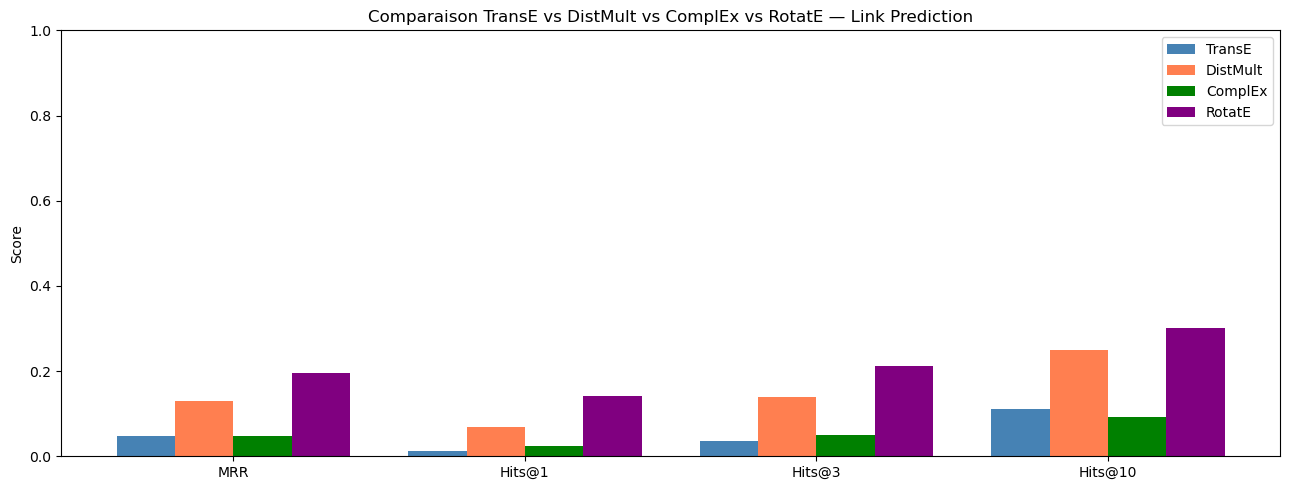

model_comparison.png sauvegardé ✓


In [23]:
# Évaluation des 4 modèles
m_transe   = get_metrics(result_transe,   'TransE')
m_distmult = get_metrics(result_distmult, 'DistMult')
m_complex  = get_metrics(result_complex,  'ComplEx')
m_rotate   = get_metrics(result_rotate,   'RotatE')

df_results = pd.DataFrame([m_transe, m_distmult, m_complex, m_rotate])
print('=== TABLEAU DE COMPARAISON — 4 MODÈLES ===')
print(df_results.to_string(index=False))
df_results.to_csv('evaluation_results.csv', index=False)
print('\nevaluation_results.csv sauvegardé ✓')

# Graphique
import matplotlib.pyplot as plt

metrics_cols = ['MRR', 'Hits@1', 'Hits@3', 'Hits@10']
x     = range(len(metrics_cols))
width = 0.2
colors = ['steelblue', 'coral', 'green', 'purple']
models = [m_transe, m_distmult, m_complex, m_rotate]
labels = ['TransE', 'DistMult', 'ComplEx', 'RotatE']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (m, label, color) in enumerate(zip(models, labels, colors)):
    offset = (i - 1.5) * width
    ax.bar([x_ + offset for x_ in x],
           [m[metric] for metric in metrics_cols],
           width, label=label, color=color)

ax.set_xticks(list(x))
ax.set_xticklabels(metrics_cols)
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Comparaison TransE vs DistMult vs ComplEx vs RotatE — Link Prediction')
ax.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print('model_comparison.png sauvegardé ✓')

---
## 5.2 KB Size Sensitivity

- On entraîne RotatE sur trois tailles de KB et on compare les performances
- plus la KB est grande, plus les embeddings sont stables


In [17]:
size_results = []

for size_name, tr_f, vl_f, te_f in [
    ('20k',  '20k_train.txt', '20k_valid.txt', '20k_test.txt'),
    ('50k',  '50k_train.txt', '50k_valid.txt', '50k_test.txt'),
    ('Full', 'train.txt',     'valid.txt',      'test.txt'),
]:
    print(f'\nEntraînement RotatE — {size_name}...')
    try:
        tf_tr = TriplesFactory.from_path(tr_f)
        tf_vl = TriplesFactory.from_path(
            vl_f, entity_to_id=tf_tr.entity_to_id,
            relation_to_id=tf_tr.relation_to_id)
        tf_te = TriplesFactory.from_path(
            te_f, entity_to_id=tf_tr.entity_to_id,
            relation_to_id=tf_tr.relation_to_id)
        res = pipeline(
            training=tf_tr, validation=tf_vl, testing=tf_te,
            model='RotatE',                          
            model_kwargs=dict(embedding_dim=100),
            optimizer_kwargs=dict(lr=0.01),
            training_kwargs=dict(num_epochs=100, batch_size=512),
            random_seed=42, device='cpu',
        )
        m_dict = res.metric_results.to_dict()
        both_r = m_dict.get('both', {}).get('realistic', {})
        size_results.append({
            'KB':       size_name,
            'Triplets': tf_tr.num_triples,
            'Entités':  tf_tr.num_entities,
            'MRR':      round(both_r.get('inverse_harmonic_mean_rank', 0), 4),
            'Hits@10':  round(both_r.get('hits_at_10', 0), 4),
        })
        print(f'  MRR={size_results[-1]["MRR"]}  Hits@10={size_results[-1]["Hits@10"]}')
    except Exception as e:
        print(f'  Erreur : {e}')
        size_results.append({'KB': size_name, 'Triplets': '?',
                              'Entités': '?', 'MRR': '?', 'Hits@10': '?'})

print('\n=== KB SIZE SENSITIVITY — RÉSULTATS ===')
print(pd.DataFrame(size_results).to_string(index=False))

INFO:pykeen.pipeline.api:Using device: cpu
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()



Entraînement RotatE — 20k...


INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
C:\Users\laura\Anaconda4\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training epochs on cpu:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/32.0 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/105 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/105 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/1.70k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 178.11s seconds


  MRR=0.1745  Hits@10=0.2869

=== KB SIZE SENSITIVITY — RÉSULTATS ===
  KB  Triplets  Entités    MRR  Hits@10
 20k     16000    15198 0.0719   0.1303
 50k     40000    34535 0.1424   0.2404
Full     53375    44788 0.1745   0.2869


## 6. Analyse des Embeddings
### 6.1 Plus proches voisins

On récupère les entités les plus proches dans l'espace vectoriel RotatE et on analyse leur cohérence sémantique.


In [19]:
from torch.nn.functional import normalize
import torch

# Récupération des embeddings RotatE
model_best  = result_rotate.model
entity_embs_raw = model_best.entity_representations[0](indices=None).detach()

#rotatE utilise des embeddings complexes donc on prend la partie réelle
if entity_embs_raw.is_complex():
    entity_embs = entity_embs_raw.real
else:
    entity_embs = entity_embs_raw

entity_ids   = tf_train.entity_to_id
id_to_entity = {v: k for k, v in entity_ids.items()}

def nearest_neighbors(entity_name, k=10):
    """Retourne les k entités les plus proches (similarité cosinus)."""
    if entity_name not in entity_ids:
        print(f'  Entité "{entity_name}" non trouvée dans le modèle.')
        return []
    idx       = entity_ids[entity_name]
    emb       = entity_embs[idx].unsqueeze(0)
    embs_norm = normalize(entity_embs, dim=1)
    emb_norm  = normalize(emb, dim=1)
    sims      = (embs_norm @ emb_norm.T).squeeze()
    topk      = torch.topk(sims, k + 1)
    return [
        (id_to_entity[i.item()], s.item())
        for s, i in zip(topk.values, topk.indices)
        if i.item() != idx
    ][:k]

#entités cibles
targets = [
    ('Q2831',   'Michael Jackson'),
    ('Q193023', 'Epic Records'),
    ('Q161819', 'Diana Ross'),
]

for qid, label in targets:
    print(f'\nPlus proches voisins de {label} ({qid}) :')
    neighbors = nearest_neighbors(qid, k=10)
    if neighbors:
        for name, score in neighbors:
            print(f'  {name:>15}  cosine = {score:.4f}')
    print()


Plus proches voisins de Michael Jackson (Q2831) :
          Q317784  cosine = 0.6727
          Q131324  cosine = 0.6570
           Q26695  cosine = 0.5760
          Q311238  cosine = 0.5690
          Q131814  cosine = 0.5638
          Q336222  cosine = 0.5635
          Q165911  cosine = 0.5635
            Q1744  cosine = 0.5582
           Q62766  cosine = 0.5547
           Q36153  cosine = 0.5515


Plus proches voisins de Epic Records (Q193023) :
          Q277626  cosine = 0.5119
          Q772494  cosine = 0.5006
          Q208909  cosine = 0.4653
          Q664167  cosine = 0.4608
          Q212699  cosine = 0.4529
        Q16959632  cosine = 0.4516
         Q3330733  cosine = 0.4307
          Q330629  cosine = 0.4258
       Q121433252  cosine = 0.4135
          Q183387  cosine = 0.4120


Plus proches voisins de Diana Ross (Q161819) :
  Entité "Q161819" non trouvée dans le modèle.



### 6.2 Clustering — t-SNE


t-SNE sur 2000 entités...


C:\Users\laura\Anaconda4\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE terminé.


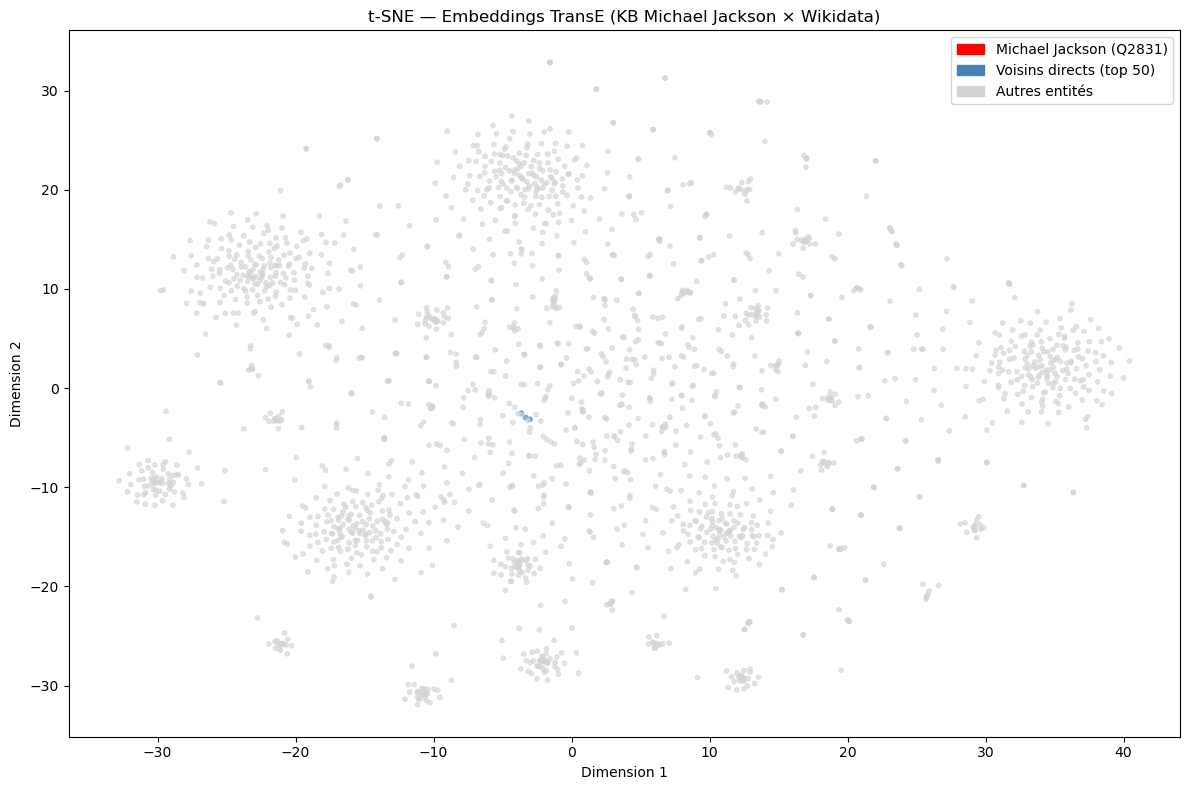

tsne_embeddings.png sauvegardé ✓


In [20]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

N = min(2000, entity_embs.shape[0])
idx_sample   = np.random.choice(entity_embs.shape[0], N, replace=False)
embs_sample  = entity_embs[idx_sample].numpy()
names_sample = [id_to_entity[i] for i in idx_sample]

print(f't-SNE sur {N} entités...')
tsne   = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
embs2d = tsne.fit_transform(embs_sample)
print('t-SNE terminé.')

mj_neighbors = {n for n, _ in nearest_neighbors('Q2831', k=50)}
colors = [
    'red'       if n == 'Q2831'          else
    'steelblue' if n in mj_neighbors     else
    'lightgray'
    for n in names_sample
]

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(embs2d[:, 0], embs2d[:, 1], c=colors, alpha=0.6, s=10)

for i, name in enumerate(names_sample):
    if name == 'Q2831':
        ax.annotate('Michael Jackson (Q2831)',
                    (embs2d[i, 0], embs2d[i, 1]),
                    fontsize=9, color='red', fontweight='bold')

legend = [
    Patch(color='red',       label='Michael Jackson (Q2831)'),
    Patch(color='steelblue', label='Voisins directs (top 50)'),
    Patch(color='lightgray', label='Autres entités'),
]
ax.legend(handles=legend)
ax.set_title('t-SNE — Embeddings TransE (KB Michael Jackson × Wikidata)')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
plt.tight_layout()
plt.savefig('tsne_embeddings.png', dpi=150)
plt.show()
print('tsne_embeddings.png sauvegardé ✓')


INFO:pykeen.pipeline.api:Using device: cpu
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
C:\Users\laura\Anaconda4\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training epochs on cpu:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/105 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/105 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/105 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/105 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/105 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/105 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/1.70k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 137.99s seconds


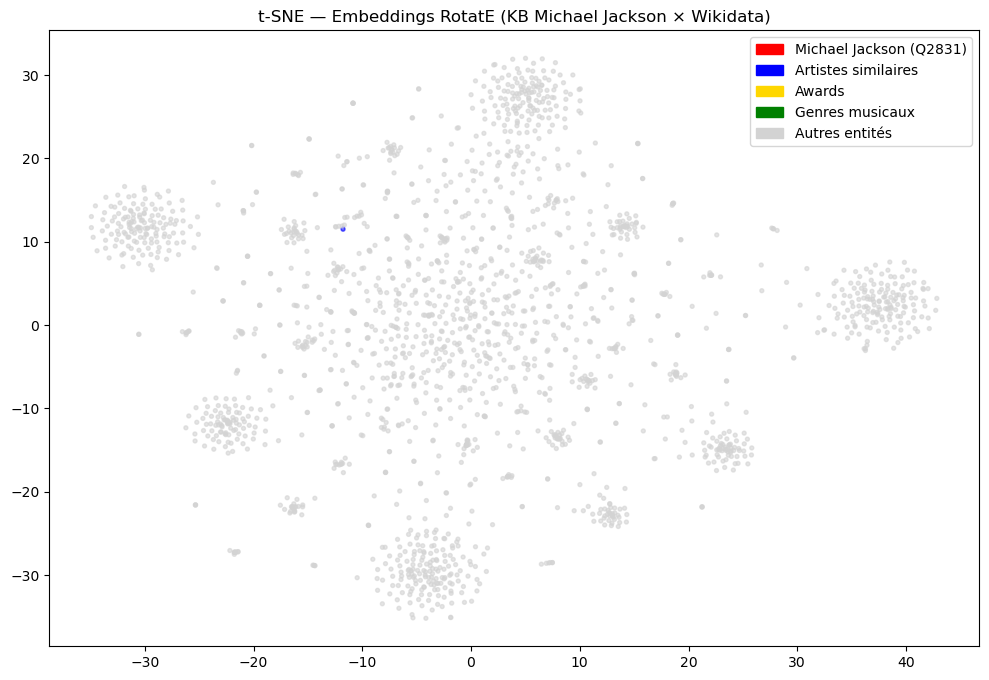

tsne_embeddings.png sauvegardé ✓


In [31]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import torch

# ── 1. Réentraîner RotatE pour avoir res accessible ──
tf_tr = TriplesFactory.from_path('train.txt')
tf_vl = TriplesFactory.from_path('valid.txt', entity_to_id=tf_tr.entity_to_id, relation_to_id=tf_tr.relation_to_id)
tf_te = TriplesFactory.from_path('test.txt',  entity_to_id=tf_tr.entity_to_id, relation_to_id=tf_tr.relation_to_id)

res = pipeline(
    training=tf_tr, validation=tf_vl, testing=tf_te,
    model='RotatE',
    model_kwargs=dict(embedding_dim=100),
    optimizer_kwargs=dict(lr=0.01),
    training_kwargs=dict(num_epochs=100, batch_size=512),
    random_seed=42, device='cpu',
)


entity_to_id = tf_tr.entity_to_id
all_ids = list(entity_to_id.keys())
indices = torch.tensor([entity_to_id[e] for e in all_ids])
embeddings = res.model.entity_representations[0](indices=indices).detach().numpy()
embeddings = embeddings.real

N = 2000
idx = np.random.choice(len(all_ids), N, replace=False)
sample_ids = [all_ids[i] for i in idx]
sample_emb = embeddings[idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
coords = tsne.fit_transform(sample_emb)

mj_neighbors = {'Q317784','Q131324','Q26695','Q311238','Q131814'}
awards        = {'Q1459443','Q953746','Q135498','Q179191'}
genres        = {'Q11401','Q45981','Q58339','Q11403'}

colors = []
for eid in sample_ids:
    if eid == 'Q2831':          colors.append('red')
    elif eid in mj_neighbors:   colors.append('blue')
    elif eid in awards:         colors.append('gold')
    elif eid in genres:         colors.append('green')
    else:                       colors.append('lightgrey')


plt.figure(figsize=(12, 8))
plt.scatter(coords[:,0], coords[:,1], c=colors, s=8, alpha=0.6)

from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(color='red',       label='Michael Jackson (Q2831)'),
    Patch(color='blue',      label='Artistes similaires'),
    Patch(color='gold',      label='Awards'),
    Patch(color='green',     label='Genres musicaux'),
    Patch(color='lightgrey', label='Autres entités'),
])
plt.title('t-SNE — Embeddings RotatE (KB Michael Jackson × Wikidata)')
plt.savefig('tsne_embeddings.png', dpi=150)
plt.show()
print('tsne_embeddings.png sauvegardé ✓')

### 6.3 Comportement des relations

On analyse trois types de relations dans l'espace RotatE :
- Symétrie : pour une relation symétrique r, RotatE apprend r ≈ -r
- Inverse : pour une paire inverse r1, r2, on attend ||r1 + r2|| ≈ 0
- Composition : vector(r1) + vector(r2) ≈ vector(r3)


In [26]:
import torch

rel_embs = model_best.relation_representations[0](indices=None).detach()
rel_ids   = tf_train.relation_to_id
id_to_rel = {v: k for k, v in rel_ids.items()}

print(f'Relations dans le modèle : {rel_embs.shape[0]}')

# symétrie 
print('\n--- Test symétrie (Phase ≈ π pour relations symétriques) ---')
for rel in ['P737', 'P463', 'P136', 'P264', 'P175']:
    if rel in rel_ids:
        r = rel_embs[rel_ids[rel]]
        # La phase moyenne en radians 
        mean_phase = torch.angle(r).mean().item()
        
        # Si la rotation est proche de π (ou -π), elle est symétrique
        is_sym = abs(abs(mean_phase) - 3.1415) < 0.6
        tag = 'symétrique' if is_sym else 'non symétrique'
        print(f'  {rel}: Phase moyenne = {mean_phase:+.4f} rad  → {tag}')

#relations inverses 
print('\n--- Test relations inverses (Produit complexe ≈ 1 + 0i) ---')
for r1n, r2n in [('P264', 'P175'), ('P463', 'P527')]:
    if r1n in rel_ids and r2n in rel_ids:
        r1 = rel_embs[rel_ids[r1n]]
        r2 = rel_embs[rel_ids[r2n]]
        
        # Le produit de deux rotations inverses doit donner une rotation nulle 
        combined = r1 * r2
        dist = torch.norm(combined - 1.0).item()
        print(f'  ||{r1n} * {r2n} - 1|| = {dist:.4f}  (proche de 0 → bonne paire inverse)')

# Composition 
print('\n--- Test composition : vector(P737) * vector(P166) ≈ ? ---')
if 'P737' in rel_ids and 'P166' in rel_ids:
    r1 = rel_embs[rel_ids['P737']]
    r2 = rel_embs[rel_ids['P166']]
    
    r_target = (r1 * r2).unsqueeze(0)
    
    target_angles = torch.angle(r_target)
    all_angles = torch.angle(rel_embs)

    sims = torch.cosine_similarity(target_angles, all_angles)
    
    topk = torch.topk(sims, 5)
    for score, i in zip(topk.values, topk.indices):
        print(f'  {id_to_rel[i.item()]:>8} : {score:.4f}')

Relations dans le modèle : 98

--- Test symétrie (Phase ≈ π pour relations symétriques) ---
  P737: Phase moyenne = +0.0581 rad  → non symétrique
  P463: Phase moyenne = +0.0478 rad  → non symétrique
  P136: Phase moyenne = -0.0475 rad  → non symétrique
  P264: Phase moyenne = +0.2467 rad  → non symétrique
  P175: Phase moyenne = +0.0713 rad  → non symétrique

--- Test relations inverses (Produit complexe ≈ 1 + 0i) ---
  ||P264 * P175 - 1|| = 13.7744  (proche de 0 → bonne paire inverse)
  ||P463 * P527 - 1|| = 13.5821  (proche de 0 → bonne paire inverse)

--- Test composition : vector(P737) * vector(P166) ≈ ? ---
     P1303 : 0.2483
      P106 : 0.2099
     P3373 : 0.1828
       P25 : 0.1780
      P358 : 0.1627


## 8. Comparaison Rule-Based vs Embedding



In [23]:

print('=== Règle : P737(p, a) ∧ P166(a, award) → P166(p, award) ===')

p737_dict = {}  # influenced_by
p166_dict = {}  # award_received

for _, row in train_df.iterrows():
    if row['predicate'] == 'P737':
        p737_dict.setdefault(row['subject'], set()).add(row['object'])
    if row['predicate'] == 'P166':
        p166_dict.setdefault(row['subject'], set()).add(row['object'])

inferred = []
for person, influences in p737_dict.items():
    for influence in influences:
        for award in p166_dict.get(influence, set()):
            inferred.append({
                'person':        person,
                'influence':     influence,
                'award_inferred': award,
                'already_in_KB': award in p166_dict.get(person, set()),
            })

df_inf = pd.DataFrame(inferred)
if not df_inf.empty:
    print(f'Triplets inférés par la règle : {len(df_inf)}')
    print(f'Déjà dans la KB              : {df_inf["already_in_KB"].sum()}')
    print(f'Nouveaux triplets inférés     : {(~df_inf["already_in_KB"]).sum()}')
    print('\nExemples de nouveaux triplets :')
    print(df_inf[~df_inf['already_in_KB']].head(5).to_string(index=False))
else:
    print('Aucun triplet inféré (P737 ou P166 absents du split train).')


=== Règle : P737(p, a) ∧ P166(a, award) → P166(p, award) ===
Triplets inférés par la règle : 3812
Déjà dans la KB              : 27
Nouveaux triplets inférés     : 3785

Exemples de nouveaux triplets :
person influence award_inferred  already_in_KB
Q39803     Q1325         Q17144          False
Q76519      Q937         Q28003          False
 Q4235      Q303      Q17985761          False
 Q4235      Q303         Q17144          False
 Q4235      Q303         Q41254          False


In [28]:
# Vérification vectorielle adaptée à RotatE 
print('\n=== Vérification par composition (Logique RotatE) ===')

if 'P737' in rel_ids and 'P166' in rel_ids:
    r_p737 = rel_embs[rel_ids['P737']]
    r_p166 = rel_embs[rel_ids['P166']]
    
    r_comp = r_p737 * r_p166
    
    angle_comp = torch.angle(r_comp).unsqueeze(0)
    angle_p166 = torch.angle(r_p166).unsqueeze(0)
    all_angles  = torch.angle(rel_embs)

    sim = torch.cosine_similarity(angle_comp, angle_p166).item()
    print(f'Similarité (phases) entre (P737 * P166) et P166 = {sim:.4f}')

    sims = torch.cosine_similarity(angle_comp, all_angles)
    topk = torch.topk(sims, 5)
    
    print('\nRelations les plus proches de la composition (P737 * P166) :')
    for score, i in zip(topk.values, topk.indices):
        print(f'  {id_to_rel[i.item()]:>8} : {score:.4f}')

    print()
    if sim > 0.7:
        print('→ La composition confirme la règle SWRL via les rotations')
    else:
        print('→ La composition ne confirme pas directement la règle.')
        print('  Note: RotatE est excellent pour la composition, mais cela dépend de l\'entraînement.')
else:
    print('P737 ou P166 absents du modèle')


=== Vérification par composition (Logique RotatE) ===
Similarité (phases) entre (P737 * P166) et P166 = 0.0177

Relations les plus proches de la composition (P737 * P166) :
     P1303 : 0.2483
      P106 : 0.2099
     P3373 : 0.1828
       P25 : 0.1780
      P358 : 0.1627

→ La composition ne confirme pas directement la règle.
  Note: RotatE est excellent pour la composition, mais cela dépend de l'entraînement.
